# Visualization comparing NLSTSeg lung lobe location to TotalSegmentator

This notebook creates a visualization comparing the lung lobe assignment of the lesions to what is generated by TotalSegmentator.

Note: The notebook 'NLSTSegVsTS.ipynb' must be run first to create the nlstseg_ts_lesion_matching_with_volume.csv file. For simplicity however, this csv file has been uploaded to the GitHub repository.

Deepa Krishnaswamy

Brigham and Women's Hospital

August 2026



# Set up the environment

In [3]:
import matplotlib.pyplot as plt
import re
import seaborn as sns
import pandas as pd

# Download the csv file from GitHub

The 'nlstseg_ts_lesion_matching_with_volume.csv' is created from the 'NLSTSegVsTs.ipynb' notebook. For simplicity, the csv file has been uploaded to GitHub

In [1]:
!wget https://raw.githubusercontent.com/ImagingDataCommons/idc-nlst-plus/refs/heads/main/TechnicalValidation/consistencyChecks/nlstseg_ts_lesion_matching_with_volume.csv

--2026-08-06 16:33:28--  https://raw.githubusercontent.com/ImagingDataCommons/idc-nlst-plus/refs/heads/main/TechnicalValidation/consistencyChecks/nlstseg_ts_lesion_matching_with_volume.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 521350 (509K) [text/plain]
Saving to: ‘nlstseg_ts_lesion_matching_with_volume.csv’

nlstseg_ts_lesion_m 100%[===================>] 509.13K  --.-KB/s    in 0.04s   

2026-08-06 16:33:29 (13.7 MB/s) - ‘nlstseg_ts_lesion_matching_with_volume.csv’ saved [521350/521350]



# Create a plot to compare NLSTSeg lesions vs TS regions

In [4]:
# 1. Load the dataset
file_path = '/content/nlstseg_ts_lesion_matching_with_volume.csv'
df = pd.read_csv(file_path)

# 2. Reformat the columns for ease of use
df_exploded = df.copy()
df_exploded['TS_segment_split'] = df_exploded['TS_segments'].str.split(',')
df_exploded = df_exploded.explode('TS_segment_split')
df_exploded['TS_segment_split'] = df_exploded['TS_segment_split'].str.strip()
df_exploded = df_exploded.reset_index(drop=True)

# Specify the order of the ribs
RIB_ORDINALS = {
    'First': 1, 'Second': 2, 'Third': 3, 'Fourth': 4, 'Fifth': 5,
    'Sixth': 6, 'Seventh': 7, 'Eighth': 8, 'Ninth': 9, 'Tenth': 10,
    'Eleventh': 11, 'Twelfth': 12,
}
NO_TS_MATCH = 'No corresponding region in TS'

def is_lung_segment(name):
    lower = name.lower()
    return 'lung' in lower and ('lobe' in lower or 'hilum' in lower)

def is_rib(name):
    return name.endswith(' rib')

def is_vertebra(name):
    return 'vertebra' in name.lower()

def rib_sort_key(name):
    ordinal = next((n for word, n in RIB_ORDINALS.items() if f'{word} rib' in name), 99)
    side = 0 if name.startswith('Left ') else 1 if name.startswith('Right ') else 2
    return (ordinal, side, name)

def vertebra_sort_key(name):
    match = re.search(r'T(\d+)', name)
    return int(match.group(1)) if match else 99

def build_col_order(row_order, all_ts_segments):
    remaining = set(all_ts_segments)
    ordered = []

    for segment in row_order:
        if is_lung_segment(segment) and segment in remaining:
            ordered.append(segment)
            remaining.remove(segment)

    if NO_TS_MATCH in remaining:
        ordered.append(NO_TS_MATCH)
        remaining.remove(NO_TS_MATCH)

    singles = sorted(s for s in remaining if not is_rib(s) and not is_vertebra(s))
    ordered.extend(singles)
    remaining -= set(singles)

    ribs = sorted((s for s in remaining if is_rib(s)), key=rib_sort_key)
    ordered.extend(ribs)
    remaining -= set(ribs)

    vertebrae = sorted((s for s in remaining if is_vertebra(s)), key=vertebra_sort_key)
    ordered.extend(vertebrae)
    remaining -= set(vertebrae)

    ordered.extend(sorted(remaining))
    return ordered


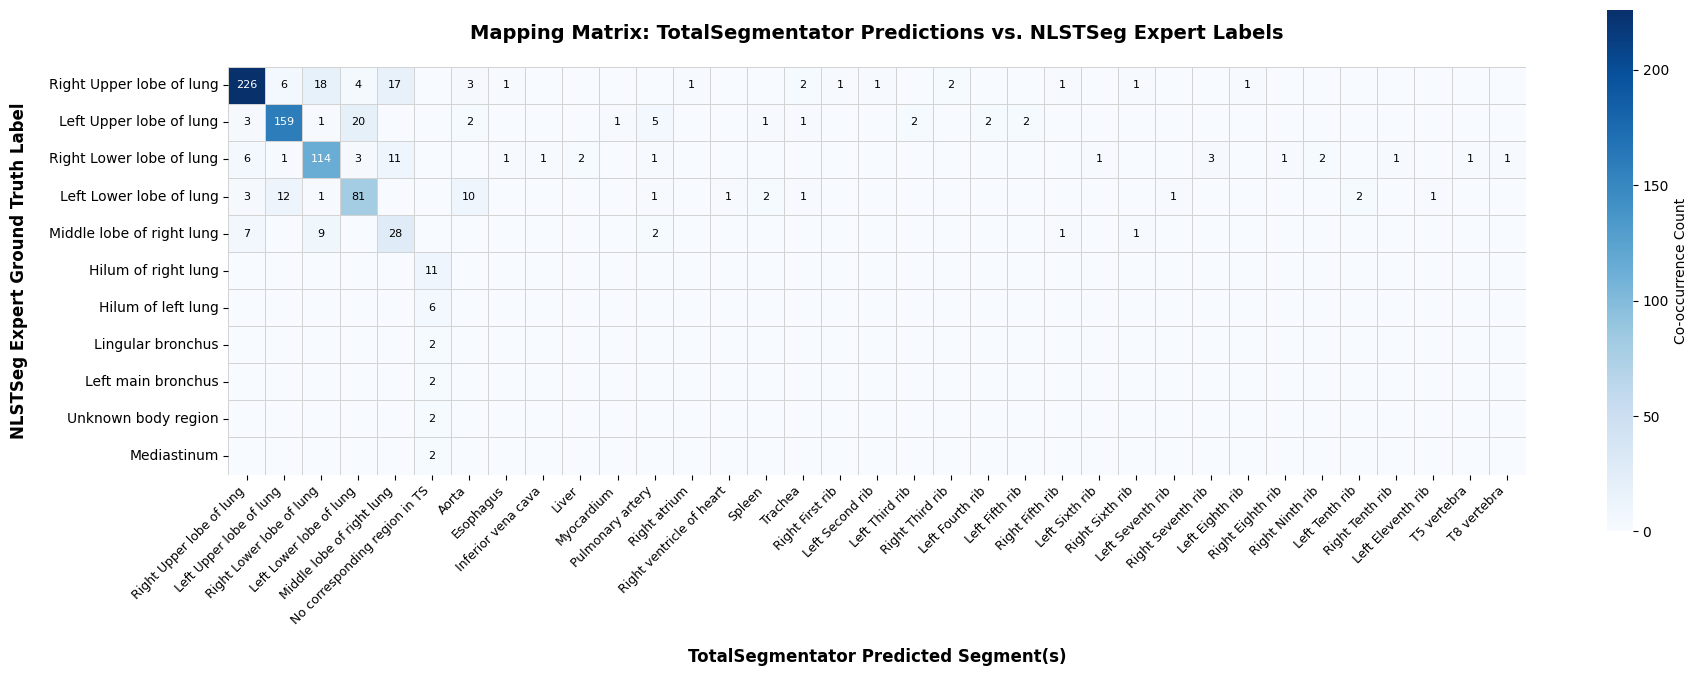

In [7]:

# 3. Determine row order by frequency; column order follows anatomical grouping
row_order = df_exploded['NLSTSeg_Segment'].value_counts().index
all_ts_segments = set(df_exploded['TS_segment_split'])
col_order = build_col_order(row_order, all_ts_segments)

# 4. Create the cross-tabulation matrix (Confusion Matrix)
ct = pd.crosstab(df_exploded['NLSTSeg_Segment'], df_exploded['TS_segment_split'])
ct = ct.loc[row_order, col_order]

# 5. Configure matplotlib style and figure size for square cells
plt.rc('font', family='sans-serif', size=10)
n_rows, n_cols = ct.shape
cell_size = 0.42  # inches per square cell
fig, ax = plt.subplots(
    figsize=(n_cols * cell_size + 4.0, n_rows * cell_size + 3.0)
)

# Draw the heatmap horizontally: TS segments across the top, NLSTSeg labels down the side
sns.heatmap(
    ct,
    annot=False,
    cmap='Blues',
    cbar_kws={'label': 'Co-occurrence Count', 'shrink': 0.8},
    linewidths=0.5,
    linecolor='lightgray',
    square=True,
    ax=ax
)

# Annotate every non-zero cell manually (seaborn DataFrame annot + fmt='' skips most rows)
count_threshold = ct.values.max() / 2
for row_idx in range(ct.shape[0]):
    for col_idx in range(ct.shape[1]):
        value = ct.iat[row_idx, col_idx]
        if value == 0:
            continue
        text_color = 'white' if value > count_threshold else 'black'
        ax.text(
            col_idx + 0.5,
            row_idx + 0.5,
            str(int(value)),
            ha='center',
            va='center',
            color=text_color,
            fontsize=8,
        )

# Set titles and labels
ax.set_title('Mapping Matrix: TotalSegmentator Predictions vs. NLSTSeg Expert Labels', fontsize=14, pad=20, weight='bold')
ax.set_xlabel('TotalSegmentator Predicted Segment(s)', fontsize=12, labelpad=15, weight='bold')
ax.set_ylabel('NLSTSeg Expert Ground Truth Label', fontsize=12, labelpad=15, weight='bold')

# Rotate x-axis labels so the horizontal axis stays readable
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=10)

# Save the matrix figure with tight bounds so the margins look crisp
plt.tight_layout()
output_filename = 'nlstseg_ts_confusion_matrix.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()